## Setup

In [1]:
import os
import json
import asyncio
import nest_asyncio
import sqlite3
import logging

from datetime import datetime

from IPython.display import Image, display
from dotenv import load_dotenv
from utils import chat_interface
from typing import Annotated, Optional, Literal, List, Dict, TypedDict
from pydantic import BaseModel, EmailStr, Field

from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph.message import MessagesState, add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, filter_messages
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import START, END, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver

from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from agentic.state_model import *
# from agentic.agents.agents import *
# from agentic.workflow import *

from langchain_tavily import TavilySearch

In [2]:
nest_asyncio.apply()

In [3]:
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
UDAHUB_DB_PATH = os.getenv("UDAHUB_DB_PATH")
CULTPASS_DB_PATH = os.getenv("CULTPASS_DB_PATH")
KNOWLEDGE_DB_PATH = os.getenv("KNOWLEDGE_DB_PATH")
llm_base_url = "https://api.openai.com/v1"

In [4]:
llm_small = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

llm_medium = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

llm_large = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

embeddings_fn = OpenAIEmbeddings(
    model="text-embedding-3-large",
    base_url=llm_base_url,
    api_key=OPENAI_API_KEY,
)

Structured Logging

In [5]:
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',
    handlers=[
        logging.FileHandler('logs/agent_activity.jsonl'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger("uda_hub")

def log_event(event_type: str, **kwargs):
    """Emit a structured log entry as JSON."""
    entry = {
        "timestamp": datetime.now().isoformat(),
        "event": event_type,
        **kwargs
    }
    logger.info(json.dumps(entry))

Setting Up MCP Client

In [6]:
server_configs = {
    "udahub": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/udahub_mcp_server.py"],
        "env": {**os.environ, "DATABASE_PATH": os.getenv("UDAHUB_DB_PATH")}
    },
    "cultpass": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/cultpass_mcp_server.py"],
        "env": {**os.environ}
    },
    "internal": {
        "transport": "stdio",
        "command": "python",
        "args": ["agentic/tools/internal_mcp_server.py"],
        "env": {**os.environ}
    }
}

# Initialize the multi-server client
mcp_client = MultiServerMCPClient(server_configs)

udahub_tools = await mcp_client.get_tools(server_name="udahub")
cultpass_tools = await mcp_client.get_tools(server_name="cultpass")
internal_tools = await mcp_client.get_tools(server_name="internal")
all_tools = await mcp_client.get_tools() + [TavilySearch(max_results=3, api_key=TAVILY_API_KEY)]

account_access_team_tools_name = ['unblock_user', 'article_rag_search']
customer_inquiry_team_tools_name = ['get_user_subscription_details', 'get_user_reservation_history', 'get_experience_availability', 'article_rag_search']
general_inquiry_team_tools_name = ['article_rag_search', 'web_search']     # Alternative: ['article_rag_search', 'web_search']

account_access_team_tools = [tool for tool in all_tools if tool.name in account_access_team_tools_name ]
customer_inquiry_team_tools = [tool for tool in all_tools if tool.name in customer_inquiry_team_tools_name ]
general_inquiry_team_tools = [tool for tool in all_tools if tool.name in general_inquiry_team_tools_name ]

# Direct MCP tool calling function
async def call_tool(tool_list: list, tool_name: str, query: dict = {}):
    my_tool = next(tool for tool in tool_list if tool.name == tool_name)
    result = await my_tool.ainvoke(query)
    raw_text = result[0].get("text", "")
    if not raw_text.strip():
        return {} # Return empty dict if there's no content
    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        # If it's not JSON, return the raw text or a status dict
        return {"status": "ok", "response": raw_text}

Hyperparameters

In [7]:
num_customer_inquiry_agents = 3
num_account_access_agents = 2
num_general_inquiry_agents = 3
escalation_threshold = 0.5

Memory Management

In [8]:
db_path = "./data/core/runtime_memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = MemorySaver()
store = InMemoryStore()

In [9]:
all_tools_name = [ tool.name for tool in all_tools ]
all_tools_name

['get_highest_urgency_ticket',
 'delete_ticket',
 'update_ticket_status',
 'get_user_ticket_history',
 'get_user_subscription_details',
 'get_user_reservation_history',
 'get_experience_availability',
 'unblock_user',
 'article_rag_search',
 'web_search',
 'tavily_search']

In [10]:
# teams_subgraph = await create_teams_graphs(num_customer_inquiry_agents, num_account_access_agents, num_general_inquiry_agents, escalation_threshold)
# agent_swarm_map = teams_subgraph["agent_swarm_map"]
# agent_teams = teams_subgraph["agent_teams"]

In [11]:
# teams_subgraph = await create_teams_graphs(
#     num_customer_inquiry_agents, 
#     num_account_access_agents, 
#     num_general_inquiry_agents, 
#     escalation_threshold
# )
# agent_swarm_map = teams_subgraph["agent_swarm_map"]
# agent_teams = teams_subgraph["agent_teams"]

# Subgraph (Inside Ticket Processing)

In [12]:
task_orchestrator_prompt = """
    You are an expert in sorting customer inquiries and forwarding to the coresponding team, please determine the team based on the following criteria:

    (1) Customer Inquiry Team: If the ticket is related to account cancellation, subscription change, or account reactivation, forward the ticket to the Customer Inquiry Team.
    (2) Account Access Team: If the ticket is related to login issues, password reset, or account lockout, billing questions, forward the ticket to the Account Access Team.
    (3) General Inquiry Team: For any other matters that do not fit the above categories, forward the ticket to the General Inquiry Team.

    Output the team name only without any explanation. The team name should be one of the following: "customer_inquiry_team", "account_access_team", "general_inquiry_team".
    """

task_orchestrator_agent = create_agent(
    name="task_orchestrator_agent",
    system_prompt=task_orchestrator_prompt,
    model=llm_small,
    response_format=OrchestratorSelection,
    )

In [13]:
customer_inquiry_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address issues related to account cancellation, subscription change, or account reactivation.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        get_user_subscription_details: Retrieve the user's current subscription details, including subscription tier and renewal date.
        get_user_reservation_history: Fetch the user's past reservation history, including dates, experiences booked, and any cancellations.
        get_experience_availability: Check the availability of specific experiences that the user is interested in, based on their preferences and past bookings.
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

customer_inquiry_agents_pool = [
    create_agent(
        name=f"customer_inquiry_agent_{member}",
        system_prompt=customer_inquiry_team_prompt,
        model=llm_medium,
        tools=customer_inquiry_team_tools,
    ) for member in range(1, num_customer_inquiry_agents+1)
]

In [14]:
account_access_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address issues related to login issues, password reset, or account lockout, billing questions.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        unblock_user: Unblock a user's account if they are locked out due to multiple failed login attempts or other security reasons.
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

account_access_agent_pool = [
    create_agent(
        name=f"account_access_agent_{member}",
        system_prompt=customer_inquiry_team_prompt,
        model=llm_medium,
        tools=account_access_team_tools,
        ) for member in range(1, num_account_access_agents+1)
]

In [15]:
general_inquiry_team_prompt = """
    You are a customer service representative.
    You are given the customer's inquiry ticket.  Your task is to address general issues outisde of account access, customer booking, and billing questions.
    Please use a considerate and empathetic tone when communicating with customers, acknowledging their concerns and providing clear, helpful information.

    You are given a set of tools to address these issues:
        article_rag_search: Search the knowledge base for relevant articles that can assist in resolving the customer's inquiry, providing summaries and links to the articles when applicable.
        web_search: Perform a web search to find up-to-date information that can help address the customer's inquiry, summarizing key findings and providing relevant links.

    If you cannot complete the task with the tools above, please stop and explain the reason.
    If you do not understand the ticket, please ask the user to clarify the inquiry.
    """

general_inquiry_agent_pool = [
    create_agent(
        name=f"general_inquiry_agent_{member}",
        system_prompt=general_inquiry_team_prompt,
        model=llm_medium,
        tools=general_inquiry_team_tools,
        ) for member in range(1, num_general_inquiry_agents+1)
]

In [16]:
agent_swarm_map = {
    "customer_inquiry_team": customer_inquiry_agents_pool,
    "account_access_team": account_access_agent_pool,
    "general_inquiry_team": general_inquiry_agent_pool,
}

In [17]:
class ConfidentScore(BaseModel):
    confident_score: Annotated[Optional[float], Field(ge=0, le=1, default=0, description="Confidence score for RAG and Web search output.")]

confidence_eval_prompt = """
    You are a customer service quality evaluation consultant, you are tasked to evaluate the quality of the
    customer service team's answer with a score from 0 to 1 where 0 is bad and 1 is good.  Only provide the
    score and nothing else.

    Output:
        confident_score: Annotated[Optional[float], Field(ge=0, le=1, default=0, description="Confidence score for RAG and Web search output.")]
    """

confidence_eval_agent = create_agent(
        name=f"confidence_evalator",
        system_prompt=confidence_eval_prompt,
        model=llm_large,
        response_format=ConfidentScore,
)

In [18]:
confidence_eval_template = PromptTemplate.from_template(
    """
    Customer's question: 
    {question}

    Customer service team's answer: 
    {answer}
    """
)

def confident_evaluator_node(state: RoundRobinState) -> Command[Literal["human_escalation", END]]:
    '''
    Evaluate the confidence level of the output
    '''
    print("Evaluating the response quality...")

    formatted_input = confidence_eval_template.format(question=state.ticket_content, answer=state.messages[-1].content)
    result = confidence_eval_agent.invoke(input = {"messages":[("user", formatted_input)]})
    
    # Convert the confidence message into SystemMessage
    # (Otherwise, system would misunderstood it as message response.)
    last_message = result['messages'][-1]
    if isinstance(last_message, AIMessage):
        converted_message = SystemMessage(content=last_message.content)
    else:
        converted_message = []

    confident_score = result['structured_response'].confident_score
    next_destination = END if confident_score > 0.7 else "human_escalation"


    # Logging
    log_event("confidence_score", ticket_id=state.ticket_id, score=confident_score, next=next_destination)

    return Command(
        update={
            "messages": converted_message,
            "confident_score": confident_score,
            },
            goto=next_destination
    )

In [19]:
agent_swarm_map = {
    "customer_inquiry_team": customer_inquiry_agents_pool,
    "account_access_team": account_access_agent_pool,
    "general_inquiry_team": general_inquiry_agent_pool,
}

In [20]:
async def user_detail_node(ticket: TicketRetrievalState) -> dict:
    """
    Extract User Information based on the user_id of the current ticket

        Args:
            ticket: The current ticket to process.
        
        Returns:
            dict: Conforming to the `TicketProcessingState` Pydantic schema, returning the information
                  combining the ticket and user details.
    """
    
    print("Retrieving user information...")

    # Retrieving high priority ticket
    tool_name = "get_user_subscription_details"
    user_detail = await call_tool(all_tools, tool_name, {"user_id": ticket.user_id})

    # Erasing the retrieved ticket
    if len(user_detail) == 0:     # Empty dictionary == User not found
        out_message = "User not found."
    else:
        out_message = f"User details retrieved successfully: \n{json.dumps(user_detail)}"

    print(out_message)
    output = {
            "messages": [SystemMessage(content=out_message)],
            **user_detail,    
        }
    
    return output

In [21]:
async def task_orchestrator_node(ticket: TicketProcessingState) -> Command[Literal["trigger_agent_team", END]]:
    '''
    Evaluate the ticket content to route the ticket to the corresponding team.
    '''
    # Being Process Ticket if Status is `Open`
    if ticket.ticket_status.lower() == 'open':
        output = await task_orchestrator_agent.ainvoke({"messages": [{"role": "system", "content": f"ticket_content: {ticket.ticket_content}"}]})
        messages = output["messages"]
        next_team = output['structured_response'].team
        next_destination = "trigger_agent_team"
    # Finish Process Ticket if Statu is `Closed` or `Human`
    else:
        next_team = None
        next_destination = END
        messages = []

        # Update ticket status in the Udahub database after processing the ticket
        tool_name = "update_ticket_status"
        _ = await call_tool(all_tools, tool_name, {"ticket_id": ticket.ticket_id, "new_status": ticket.ticket_status.lower()})

    # Logging
    log_event("routing_decision", ticket_id=ticket.ticket_id, team=next_team, ticket_content_preview=ticket.ticket_content[:80])

    return Command(
        update={
            "messages": messages,
            "ticket_status": ticket.ticket_status,
            "team_to_call": next_team,
            },
            goto=next_destination
    )

In [22]:
async def trigger_agent_team_node(state: TicketProcessingState, config: RunnableConfig):
    '''
    Node Contain Subgraph for Multiple Ticket Processing Agent Teams
    '''
    
    team_to_call = state.team_to_call

    agent_teams: dict[str,CompiledStateGraph] = config["configurable"]["agent_teams"]
    agent_swarm_map = config["configurable"]["agent_swarm_map"]
    agent_pool_to_call: List[CompiledStateGraph] = agent_swarm_map[team_to_call]

    if team_to_call in agent_teams.keys():
        team = agent_teams[team_to_call]
        agent_names = [agent.name for agent in agent_pool_to_call]
        # print(f"Agent Names: {agent_names}")
        agent_input = state.model_dump()
        agent_input['agent_names'] = agent_names
        # print(f"Agent Input: {agent_input}")
        agent_input = RoundRobinState(**agent_input)
        result = await team.ainvoke(
            input=agent_input,
            config={
                "configurable": {
                    "thread_id": "round_robin"
                }
            }
        )
        result['ticket_status'] = 'closed' if result['ticket_status'] == 'open' else result['ticket_status']

        return result
    else:
        raise ValueError("team_to_call is not inside agent_teams")  

### Round-Robin Team Subgraph

This approch allow the architecture to scale across the layer

In [23]:
def update_index_node(state: RoundRobinState):
    '''
    Index Update Node at the Graph Entrance
    '''
    state = state.model_dump()
    agent_names = state["agent_names"]
    current_agent_index = state.get("current_agent_index", 0)
    current_agent_index = 0 if current_agent_index is None else current_agent_index
    new_agent_index = current_agent_index + 1  
    new_agent_index_in_range = new_agent_index % len(agent_names)
    print(f"new_agent_index_in_range: {new_agent_index_in_range}")
    return {
        "current_agent_index": new_agent_index_in_range
    }

In [24]:
def route_round_robin(state: RoundRobinState):
    '''
    Routing Function for Round-Robin Agents
    '''
    state = state.model_dump()
    agent_names = state["agent_names"]
    current_agent_index = state.get("current_agent_index", 0)
    current_agent_index = 0 if current_agent_index is None else current_agent_index
    current_agent_index_in_range = current_agent_index % len(agent_names)
    active_agent = agent_names[current_agent_index_in_range]
    print("Round-robin Active Agent:", active_agent)

    log_event("team_invoked", team=state["team_to_call"], agent_index=state["current_agent_index"])

    return active_agent

In [25]:
confidence_eval_template = PromptTemplate.from_template(
    """
    Customer's question: 
    {question}

    Customer service team's answer: 
    {answer}
    """
)

async def confident_evaluator_node(state: RoundRobinState) -> Command[Literal["human_escalation", END]]:
    '''
    Evaluate the confidence level of the output
    '''
    print("Evaluating the response quality...")

    formatted_input = confidence_eval_template.format(question=state.ticket_content, answer=state.messages[-1].content)
    result = await confidence_eval_agent.ainvoke(input = {"messages":[("user", formatted_input)]})
    
    # Convert the confidence message into SystemMessage
    # (Otherwise, system would misunderstood it as message response.)
    last_message = result['messages'][-1]
    if isinstance(last_message, AIMessage):
        converted_message = SystemMessage(content=last_message.content)
    else:
        converted_message = []

    confident_score = result['structured_response'].confident_score
    next_destination = END if confident_score > 0.7 else "human_escalation"

    # Logging
    log_event("confidence_score", ticket_id=state.ticket_id, score=confident_score, next=next_destination)

    return Command(
        update={
            "messages": converted_message,
            "confident_score": confident_score,
            },
            goto=next_destination
    )

In [26]:
def human_escalation_node(state: RoundRobinState) -> dict:  
    '''
    Escalate to Human
        Description:
            Mark the ticket for human review in the database
    '''
    print('Updating ticket status for human agent to process later...')
    return {'ticket_status': 'Human'}
    

In [27]:
def create_rr_team_workflow(name:str, agent_pool: List[CompiledStateGraph]):
    '''
    Building Graph for a Single Team of Multiple RR Agents

        Args:
            name: The name given to the created team graph
            agent_pool: The dictionary wit the member agents of this team (key: agent name, value: compiled graph agent)
        
        Returns:
            workflow: StateGraph type for the workflow to be modified with post-processing step
    '''
    workflow = StateGraph(RoundRobinState)

    workflow.add_node("update_index", update_index_node)
    for agent in agent_pool:
        workflow.add_node(agent.name, agent)

    workflow.add_edge(START, "update_index")
    workflow.add_conditional_edges(
        source="update_index",
        path=route_round_robin,
        path_map=[agent.name for agent in agent_pool]
    )
    # --- Old Code: Workflow is produced instead of Compiled Graph because confident evaluation need to be added for only 1 path ---
    # graph = workflow.compile(name=name, checkpointer=MemorySaver())
    # return graph
    return workflow

In [28]:
# List of Graph for Each Team

agent_teams_workflow = { team_name: create_rr_team_workflow(team_name, agent_pool) for team_name, agent_pool in agent_swarm_map.items() }

team = 'general_inquiry_team'
modify_workflow = agent_teams_workflow[team]
modify_workflow.add_node("confident_evaluator", confident_evaluator_node)
modify_workflow.add_node("human_escalation", human_escalation_node)
for agent in agent_swarm_map[team]:
    modify_workflow.add_edge(agent.name, "confident_evaluator")

agent_teams_workflow[team] = modify_workflow

agent_teams = { key: value.compile(name=key, checkpointer=checkpointer) for key, value in agent_teams_workflow.items() }

In [29]:
agent_teams

{'customer_inquiry_team': <langgraph.graph.state.CompiledStateGraph at 0x128a8a090>,
 'account_access_team': <langgraph.graph.state.CompiledStateGraph at 0x128a8bb10>,
 'general_inquiry_team': <langgraph.graph.state.CompiledStateGraph at 0x128916b10>}

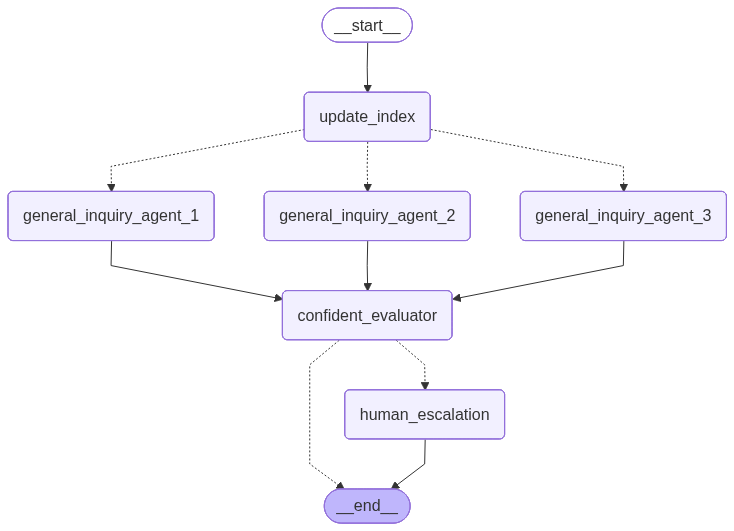

In [30]:
team_name = 'general_inquiry_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

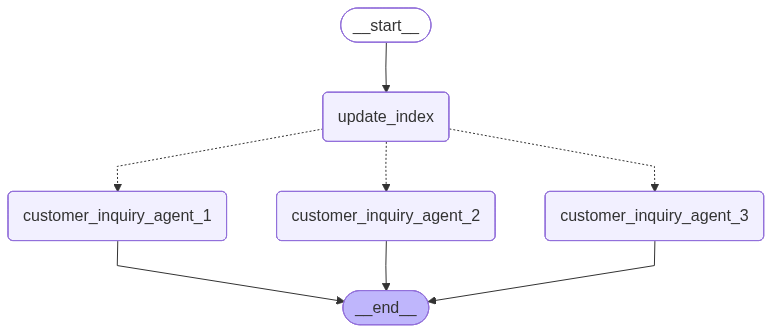

In [31]:
team_name = 'customer_inquiry_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

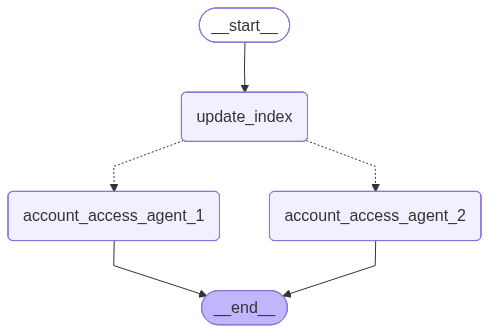

In [32]:
team_name = 'account_access_team'
display(
    Image(
        agent_teams[team_name].get_graph().draw_mermaid_png()
    )
)

## State Graph Definition

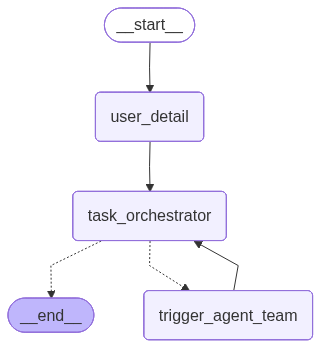

In [33]:
workflow = StateGraph(TicketProcessingState)

workflow.add_node("user_detail", user_detail_node)
workflow.add_node("task_orchestrator", task_orchestrator_node)
workflow.add_node("trigger_agent_team", trigger_agent_team_node)

workflow.add_edge(START, "user_detail")
workflow.add_edge("user_detail", "task_orchestrator")
workflow.add_edge("trigger_agent_team", "task_orchestrator")

ticket_processing_graph = workflow.compile(checkpointer=checkpointer, store=store)

display(
    Image(
        ticket_processing_graph.get_graph().draw_mermaid_png()
    )
)

# Main Graph

In [34]:
# tool_name = "get_highest_urgency_ticket"
# tool_list = all_tools
# query = {}

# response = await call_tool(all_tools, tool_name)
# ticket = response['ticket']
# ticket

# config = {
#     "configurable": {
#         "thread_id": "Test_run",
#         "agent_teams": agent_teams,
#         "agent_swarm_map": agent_swarm_map,
#         "recursion_limit": 100,
#     }
# }
# tool_name = "get_highest_urgency_ticket"
# response = await call_tool(all_tools, tool_name)
# ticket = response['ticket']
# ticket_content = ticket['ticket_content']
# print(f"Ticket Tag: {ticket['ticket_tag']}")
# print(f"Ticket: {ticket_content}")
# response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
# response_content = response["messages"][-1].content
# response_content

In [35]:
# Agent Input: {
#     'messages': [{'content': 'Start processing tickets.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '8bb7004d-3a47-494d-a52e-a5b115e114b9'}, 
#                  {'content': 'User not found.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': '96dce5d1-e0aa-4abf-aec1-8abd2995eb87'}, 
#                  {'content': "ticket_content: Hi, I'm trying to understand the pricing structure for your services. It seems a bit confusing, and I want to make sure I'm getting the best deal. Can you provide more clarity on this?", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': '3e409528-97f4-40ab-a750-a33d69c103ef'}, 
#                  {'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 20, 'prompt_tokens': 276, 'total_tokens': 296, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWA6VCrpyh00xsjIkef5HIabOInTA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, 'type': 'ai', 'name': None, 'id': 'lc_run--019da317-4956-7d33-96eb-94299c426cf4-0', 'tool_calls': [{'name': 'OrchestratorSelection', 'args': {'team': 'general_inquiry_team'}, 'id': 'call_lWiyEIW6py8rPUL0UdFskktB', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 276, 'output_tokens': 20, 'total_tokens': 296, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}}, 
#                  {'content': "Returning structured response: team='general_inquiry_team'", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'OrchestratorSelection', 'id': '3d7f1701-5aa2-458d-abd3-933bcceac8eb', 'tool_call_id': 'call_lWiyEIW6py8rPUL0UdFskktB', 'artifact': None, 'status': 'success'}, {'content': 'Start processing tickets.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '4db19ac0-877f-445e-9e68-8aa5c6aee5ff'}, 
#                  {'content': 'User not found.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': '10dae786-1963-41c8-a8f1-953691f9ec81'}, {'content': "ticket_content: Hi, I'm trying to understand the pricing structure for your services. It seems a bit confusing, and I want to make sure I'm getting the best deal. Can you provide more clarity on this?", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': '5b5734cc-f724-4cfd-82a3-8da4c9145cfb'}, 
#                  {'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 20, 'prompt_tokens': 276, 'total_tokens': 296, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWA7NTFvPU9AyDMBTUpPdqrkpAIPS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, 'type': 'ai', 'name': None, 'id': 'lc_run--019da318-1e23-72f1-bb58-ee9448af82ef-0', 'tool_calls': [{'name': 'OrchestratorSelection', 'args': {'team': 'general_inquiry_team'}, 'id': 'call_J2S4kofnoOqozD2LYKTMvu3P', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 276, 'output_tokens': 20, 'total_tokens': 296, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}}, 
#                  {'content': "Returning structured response: team='general_inquiry_team'", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'OrchestratorSelection', 'id': '056dc95b-5f39-4fec-a84d-ca7e20b7542c', 'tool_call_id': 'call_J2S4kofnoOqozD2LYKTMvu3P', 'artifact': None, 'status': 'success'}, {'content': 'Start processing tickets.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '1ce16617-2402-4772-83a5-6f5263fb2245'}, {'content': 'User not found.', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': '7735b88f-a7b1-47ae-8c4d-c8b35a1be3a5'}, 
#                  {'content': "ticket_content: Hi, I'm trying to understand the pricing structure for your services. It seems a bit confusing, and I want to make sure I'm getting the best deal. Can you provide more clarity on this?", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'system', 'name': None, 'id': 'c766e4d7-32d0-4cc1-b0cc-8d398c043560'}, 
#                  {'content': '', 'additional_kwargs': {'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 20, 'prompt_tokens': 276, 'total_tokens': 296, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DWABFuycg0e2BtHT1u8XYsT1TrzOq', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, 'type': 'ai', 'name': None, 'id': 'lc_run--019da31b-c4fc-7ec1-a32b-cc286e2edd32-0', 'tool_calls': [{'name': 'OrchestratorSelection', 'args': {'team': 'general_inquiry_team'}, 'id': 'call_Rz1UUpP8Bsb7awhd8s2fkecc', 'type': 'tool_call'}], 'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 276, 'output_tokens': 20, 'total_tokens': 296, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}}, 
#                  {'content': "Returning structured response: team='general_inquiry_team'", 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'tool', 'name': 'OrchestratorSelection', 'id': '5eca37d3-205a-40c5-a72d-44d84ad3c221', 'tool_call_id': 'call_Rz1UUpP8Bsb7awhd8s2fkecc', 'artifact': None, 'status': 'success'}], 
#     'user_id': '0eb068', 
#     'account_id': 'cultpass', 
#     'ticket_id': 'f65dda97-ef51-4b31-8e86-152c4f6c32c7', 
#     'ticket_content': "Hi, I'm trying to understand the pricing structure for your services. It seems a bit confusing, and I want to make sure I'm getting the best deal. Can you provide more clarity on this?", 
#     'ticket_tag': 'pricing', 
#     'ticket_channel': 'web', 
#     'ticket_urgency': 0.7685027120849381, 
#     'ticket_status': 'open', 'user_status': None, 'user_tier': None, 'user_is_blocked': False, 'user_name': None, 'user_email': None, 'team_to_call': 'general_inquiry_team', 'agent_names': ['general_inquiry_agent_1', 'general_inquiry_agent_2', 'general_inquiry_agent_3']}


In [36]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I noticed an unexpected charge on my latest bill. I believe there might be a mistake, as I didn't make any additional purchases. Could you please look into this and let me know what happened? If necessary, I would like to escalate this issue to ensure it's resolved promptly. Thank you for your assistance.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:34.129760", "event": "routing_decision", "ticket_id": "f7486ad4-54cb-4a58-b71f-cbdfde43cf60", "team": "account_access_team", "ticket_content_preview": "Hi, I noticed an unexpected charge on my latest bill. I believe there might be a"}
{"timestamp": "2026-04-19T02:42:34.133727", "event": "team_invoked", "team": "account_access_team", "agent_index": 1}


new_agent_index_in_range: 1
Round-robin Active Agent: account_access_agent_2


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:37.005099", "event": "routing_decision", "ticket_id": "f7486ad4-54cb-4a58-b71f-cbdfde43cf60", "team": null, "ticket_content_preview": "Hi, I noticed an unexpected charge on my latest bill. I believe there might be a"}


'I understand your concern regarding the unexpected charge on your latest bill, and I’m here to help you resolve this issue. To assist you better, I will need to check your account details, including your current subscription and any recent transactions.\n\nCould you please provide me with your account information or user ID so I can look into this for you? Thank you for your patience!'

In [37]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hello, I need to cancel my subscription. I've tried doing it through the website, but the option isn't available. Could you please assist me with this? Thank you.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:39.917802", "event": "routing_decision", "ticket_id": "1480424b-55eb-4cbf-aef8-061b062be369", "team": "customer_inquiry_team", "ticket_content_preview": "Hello, I need to cancel my subscription. I've tried doing it through the website"}
{"timestamp": "2026-04-19T02:42:39.921930", "event": "team_invoked", "team": "customer_inquiry_team", "agent_index": 2}


new_agent_index_in_range: 2
Round-robin Active Agent: customer_inquiry_agent_3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:42.811478", "event": "routing_decision", "ticket_id": "1480424b-55eb-4cbf-aef8-061b062be369", "team": null, "ticket_content_preview": "Hello, I need to cancel my subscription. I've tried doing it through the website"}


"I understand that you would like to cancel your subscription, and I'm here to assist you with that. It can be frustrating when the option isn't available online, but I can help you with the cancellation process.\n\nTo proceed, I will need to check your current subscription details. Could you please provide me with your account information or user ID? This will allow me to assist you more effectively. Thank you for your understanding!"

In [38]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I'm having trouble accessing my account. Every time I try to log in, it says my account is locked. I haven't received any emails about this, so I'm not sure what's going on. Could you please help me resolve this issue? Thank you.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:45.297849", "event": "routing_decision", "ticket_id": "fb135539-9fb8-4931-8030-b95aeb505394", "team": "account_access_team", "ticket_content_preview": "Hi, I'm having trouble accessing my account. Every time I try to log in, it says"}
{"timestamp": "2026-04-19T02:42:45.300684", "event": "team_invoked", "team": "account_access_team", "agent_index": 1}


new_agent_index_in_range: 1
Round-robin Active Agent: account_access_agent_2


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:48.372403", "event": "routing_decision", "ticket_id": "fb135539-9fb8-4931-8030-b95aeb505394", "team": null, "ticket_content_preview": "Hi, I'm having trouble accessing my account. Every time I try to log in, it says"}


"I understand how concerning it can be to have trouble accessing your account, especially when you haven't received any notifications about it being locked. I'm here to help you resolve this issue.\n\nTo assist you further, I will need your account information or user ID to unlock your account. Please provide that information, and I will take care of it right away. Thank you for your patience!"

In [39]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I have a question about the weather forecast for this weekend. I noticed some changes recently, and I'm not sure if they're part of the new plan. Could you please clarify this for me? Thank you.
Retrieving user information...
User details retrieved successfully: 
{"user_name": "Eva Green", "user_status": "active", "user_tier": "basic", "user_is_blocked": false, "user_email": "eva.green@ecosoul.net"}


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:51.216940", "event": "routing_decision", "ticket_id": "052f4dbb-2ae2-4208-9dc7-12bd39ad5a34", "team": "general_inquiry_team", "ticket_content_preview": "Hi, I have a question about the weather forecast for this weekend. I noticed som"}
{"timestamp": "2026-04-19T02:42:51.222381", "event": "team_invoked", "team": "general_inquiry_team", "agent_index": 2}


new_agent_index_in_range: 2
Round-robin Active Agent: general_inquiry_agent_3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Evaluating the response quality...


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:42:59.920186", "event": "confidence_score", "ticket_id": "052f4dbb-2ae2-4208-9dc7-12bd39ad5a34", "score": 0.9, "next": "__end__"}
{"timestamp": "2026-04-19T02:43:00.919512", "event": "routing_decision", "ticket_id": "052f4dbb-2ae2-4208-9dc7-12bd39ad5a34", "team": null, "ticket_content_preview": "Hi, I have a question about the weather forecast for this weekend. I noticed som"}


'{"confident_score":0.9}'

In [40]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I need to cancel my subscription. I've tried doing it through the website, but the option isn't available. Could you please assist me with this? Thank you.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:03.311776", "event": "routing_decision", "ticket_id": "ac608554-4f0a-4db6-9e0f-c2008f431c50", "team": "customer_inquiry_team", "ticket_content_preview": "Hi, I need to cancel my subscription. I've tried doing it through the website, b"}
{"timestamp": "2026-04-19T02:43:03.318010", "event": "team_invoked", "team": "customer_inquiry_team", "agent_index": 0}


new_agent_index_in_range: 0
Round-robin Active Agent: customer_inquiry_agent_1


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:06.468049", "event": "routing_decision", "ticket_id": "ac608554-4f0a-4db6-9e0f-c2008f431c50", "team": null, "ticket_content_preview": "Hi, I need to cancel my subscription. I've tried doing it through the website, b"}


"I understand that you're having trouble canceling your subscription, and I'm here to help you with that. It can be frustrating when the online option isn't available.\n\nTo assist you further, I will need to check your current subscription details. Could you please provide me with your account information or user ID? This will allow me to process your cancellation request promptly. Thank you for your understanding!"

In [41]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hello, I need help with my account password. Every time I try to reset it, the link doesn't work. Could you please assist me with this? Thank you.
Retrieving user information...
User details retrieved successfully: 
{"user_name": "Frank Ocean", "user_status": "cancelled", "user_tier": "premium", "user_is_blocked": false, "user_email": "frank.ocean@seawaves.io"}


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:09.159989", "event": "routing_decision", "ticket_id": "e7f71fe3-cf4e-4455-b034-15f5e531dd63", "team": "account_access_team", "ticket_content_preview": "Hello, I need help with my account password. Every time I try to reset it, the l"}
{"timestamp": "2026-04-19T02:43:09.165856", "event": "team_invoked", "team": "account_access_team", "agent_index": 1}


new_agent_index_in_range: 1
Round-robin Active Agent: account_access_agent_2


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:11.925184", "event": "routing_decision", "ticket_id": "e7f71fe3-cf4e-4455-b034-15f5e531dd63", "team": null, "ticket_content_preview": "Hello, I need help with my account password. Every time I try to reset it, the l"}


"I understand how frustrating it can be to have trouble resetting your password, and I'm here to help you with that. \n\nSince the reset link isn't working for you, I can assist you in unlocking your account or resetting your password directly. Please provide me with your account information or user ID, and I will take care of it right away. Thank you for your patience!"

In [42]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hello, I was trying to book tickets for an event, but the website keeps crashing. I've tried different browsers, but nothing seems to work. Could you please help me with this? I don't want to miss out on the event. Thank you.
Retrieving user information...
User details retrieved successfully: 
{"user_name": "David Noir", "user_status": "cancelled", "user_tier": "premium", "user_is_blocked": true, "user_email": "david.noir@shadowmail.com"}


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:14.365895", "event": "routing_decision", "ticket_id": "1523ecab-f2fa-46ce-85d4-458a2d1e7059", "team": "general_inquiry_team", "ticket_content_preview": "Hello, I was trying to book tickets for an event, but the website keeps crashing"}
{"timestamp": "2026-04-19T02:43:14.370859", "event": "team_invoked", "team": "general_inquiry_team", "agent_index": 2}


new_agent_index_in_range: 2
Round-robin Active Agent: general_inquiry_agent_3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Evaluating the response quality...


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:24.153478", "event": "confidence_score", "ticket_id": "1523ecab-f2fa-46ce-85d4-458a2d1e7059", "score": 1.0, "next": "__end__"}
{"timestamp": "2026-04-19T02:43:25.258383", "event": "routing_decision", "ticket_id": "1523ecab-f2fa-46ce-85d4-458a2d1e7059", "team": null, "ticket_content_preview": "Hello, I was trying to book tickets for an event, but the website keeps crashing"}


'{"confident_score":1}'

In [43]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hello, I need help with my account login. Every time I try to log in, it says my password is incorrect. I've tried resetting it, but the link doesn't work. Could you please assist me with this? Thank you.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:27.880988", "event": "routing_decision", "ticket_id": "cb2e7547-d2f6-40e3-8101-3fbd96f51b91", "team": "account_access_team", "ticket_content_preview": "Hello, I need help with my account login. Every time I try to log in, it says my"}
{"timestamp": "2026-04-19T02:43:27.884849", "event": "team_invoked", "team": "account_access_team", "agent_index": 1}


new_agent_index_in_range: 1
Round-robin Active Agent: account_access_agent_2


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:31.043648", "event": "routing_decision", "ticket_id": "cb2e7547-d2f6-40e3-8101-3fbd96f51b91", "team": null, "ticket_content_preview": "Hello, I need help with my account login. Every time I try to log in, it says my"}


"I understand how frustrating it can be to have trouble logging into your account, especially when the password reset link isn't working. I'm here to help you resolve this issue.\n\nSince you're unable to reset your password, I can assist you in unlocking your account or resetting your password directly. Please provide me with your account information or user ID, and I will take care of it right away. Thank you for your patience!"

In [44]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hello, I was trying to book a hotel room for my upcoming trip, but the website keeps showing an error message. I've tried multiple times, but it just won't go through. Can you please help me with this? I would really appreciate it if you could reserve a room for me. Thank you!
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:33.722448", "event": "routing_decision", "ticket_id": "5a67160d-ad9d-47c8-9e9e-7e9a1c6092ad", "team": "general_inquiry_team", "ticket_content_preview": "Hello, I was trying to book a hotel room for my upcoming trip, but the website k"}
{"timestamp": "2026-04-19T02:43:33.798639", "event": "team_invoked", "team": "general_inquiry_team", "agent_index": 2}


new_agent_index_in_range: 2
Round-robin Active Agent: general_inquiry_agent_3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Evaluating the response quality...


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:44.480480", "event": "confidence_score", "ticket_id": "5a67160d-ad9d-47c8-9e9e-7e9a1c6092ad", "score": 0.9, "next": "__end__"}
{"timestamp": "2026-04-19T02:43:45.500789", "event": "routing_decision", "ticket_id": "5a67160d-ad9d-47c8-9e9e-7e9a1c6092ad", "team": null, "ticket_content_preview": "Hello, I was trying to book a hotel room for my upcoming trip, but the website k"}


'{"confident_score":0.9}'

In [45]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I need help with my account password. Every time I try to reset it, the link doesn't work. Could you please assist me with this? Thank you.
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:48.134186", "event": "routing_decision", "ticket_id": "8c732cf6-52ba-41d7-91f4-80cb4031c78a", "team": "account_access_team", "ticket_content_preview": "Hi, I need help with my account password. Every time I try to reset it, the link"}
{"timestamp": "2026-04-19T02:43:48.137725", "event": "team_invoked", "team": "account_access_team", "agent_index": 1}


new_agent_index_in_range: 1
Round-robin Active Agent: account_access_agent_2


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:51.240682", "event": "routing_decision", "ticket_id": "8c732cf6-52ba-41d7-91f4-80cb4031c78a", "team": null, "ticket_content_preview": "Hi, I need help with my account password. Every time I try to reset it, the link"}


"I understand how frustrating it can be to have trouble resetting your password, and I'm here to help you with that.\n\nSince the reset link isn't working for you, I can assist you in unlocking your account or resetting your password directly. Please provide me with your account information or user ID, and I will take care of it right away. Thank you for your patience!"

In [46]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

Ticket: Hi, I was trying to book a hotel room for my upcoming trip, but the website keeps showing an error message. I've tried multiple times, but it just won't go through. Can you please help me with this? I would really appreciate it if you could reserve a room for me. Thank you!
Retrieving user information...
User not found.


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:43:53.788247", "event": "routing_decision", "ticket_id": "214e6f30-a4f5-400c-93a4-3a680e9563f6", "team": "general_inquiry_team", "ticket_content_preview": "Hi, I was trying to book a hotel room for my upcoming trip, but the website keep"}
{"timestamp": "2026-04-19T02:43:53.793017", "event": "team_invoked", "team": "general_inquiry_team", "agent_index": 2}


new_agent_index_in_range: 2
Round-robin Active Agent: general_inquiry_agent_3


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Evaluating the response quality...


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
{"timestamp": "2026-04-19T02:44:01.435380", "event": "confidence_score", "ticket_id": "214e6f30-a4f5-400c-93a4-3a680e9563f6", "score": 0.9, "next": "__end__"}
{"timestamp": "2026-04-19T02:44:02.460996", "event": "routing_decision", "ticket_id": "214e6f30-a4f5-400c-93a4-3a680e9563f6", "team": null, "ticket_content_preview": "Hi, I was trying to book a hotel room for my upcoming trip, but the website keep"}


'{"confident_score":0.9}'

In [ ]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
    }
}
tool_name = "get_highest_urgency_ticket"
response = await call_tool(all_tools, tool_name)
ticket = response['ticket']
ticket_content = ticket['ticket_content']
print(f"Ticket: {ticket_content}")
response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets.", **ticket}, config=config)
response_content = response["messages"][-1].content
response_content

In [ ]:
async def process_ticket():
    print("Processing tickets from Udahub database...")
    # Get Ticket by Calling MCP Tool Manually
    tool_name = "get_highest_urgency_ticket"
    ticket_response = await call_tool(all_tools, tool_name)
    ticket = ticket_response['ticket']
    ticket_content = ticket["ticket_content"]
    print(f"Ticket: {ticket_content}")
    if not ticket:
        print("<There is no more tickets in the queue to process.>")
        success = False
    else:
        process_response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets."}, config=config)
        response_ai = filter_messages(
            process_response["messages"],
            include_types=[AIMessage],
            )
        response_content = response_ai[-1].content
        print(f"AI: {response_content}")
        # Delete ticket after processing
        # tool_name = "delete_ticket"
        # _ = await call_tool(all_tools, tool_name, {"ticket_id": ticket['ticket_id']})
        success = True
    return success

In [ ]:
config = {
    "configurable": {
        "thread_id": "Test_run",
        "agent_teams": agent_teams,
        "agent_swarm_map": agent_swarm_map,
        "recursion_limit": 100,
        "store": store,
    }
}

async def process_ticket():
    print("Processing tickets from Udahub database...")
    # Get Ticket by Calling MCP Tool Manually
    tool_name = "get_highest_urgency_ticket"
    ticket_response = await call_tool(all_tools, tool_name)
    ticket = ticket_response['ticket']
    ticket_content = ticket["ticket_content"]
    print(f"Ticket: {ticket_content}")
    if not ticket:
        print("<There is no more tickets in the queue to process.>")
        success = False
    else:
        process_response = await ticket_processing_graph.ainvoke(input={"messages": "Start processing tickets."}, config=config)
        response_ai = filter_messages(
            process_response["messages"],
            include_types=[AIMessage],
            )
        response_content = response_ai[-1].content
        print(f"AI: {response_content}")
        # Delete ticket after processing
        # tool_name = "delete_ticket"
        # _ = await call_tool(all_tools, tool_name, {"ticket_id": ticket['ticket_id']})
        success = True
    return success

async def run():
    '''
    Main Routine of Chatbot
    '''
    user_id = input("Please enter your User ID: ").strip().lower()
    if not user_id:
        user_id = "default_user"
    
    print('''
          Welcome to ChatService, you have the following options:
                (1) Type 'quit' or 'exit' if you want to leave anytime.
                (2) Press ENTER without any input to process the next ticket in the queue.
                (3) Type 'all' to process all tickets in the queue.
                (4) Type your query directly to get response from the chatbot.
          ''')
    print("Please type your question:")

    while True:
        try:
            user_input = input(">> ").strip().lower()
            if user_input in ["quit", "exit"]:
                print("Exiting...")
                break
            elif len(user_input) == 0:
                _ = await process_ticket()
            elif user_input == "all":
                while True:
                    success = await process_ticket()
                    if success == False:
                        break
            else:
                input = {
                    "messages": "Start processing ticket.",
                    "user_id": user_id,
                    "ticket_content": user_input,
                    "ticket_id": "live_session",
                    "ticket_channel": "live_chatbot",
                    "ticket_urgency": 1,
                }
                result = await ticket_processing_graph.ainvoke(input=input, config=config)
                print(result.message.content)
        except KeyboardInterrupt:
            print("Exiting...")
            break

In [ ]:
await run()